# Customer Churn EDA

Use this notebook to inspect the raw churn dataset, understand feature distributions, and identify useful preprocessing steps.

In [1]:
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

DATA_PATH = r"C:\Users\Kevin jesu\OneDrive\Desktop\ml churn\data\raw\Telco_customer_churn.xlsx"
df = pd.read_excel(DATA_PATH)
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [2]:
df.info()
df.describe(include='all').T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,7043,7043,3668-QPYBK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Count,7043.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
Country,7043,1,United States,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,7043,1,California,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,7043,1129,Los Angeles,305,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zip Code,7043.0,NaN,NaN,NaN,93521.964646,1865.794555,90001.0,92102.0,93552.0,95351.0,96161.0
Lat Long,7043,1652,"33.964131, -118.272783",5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,7043.0,NaN,NaN,NaN,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,NaN,NaN,NaN,-119.79888,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN


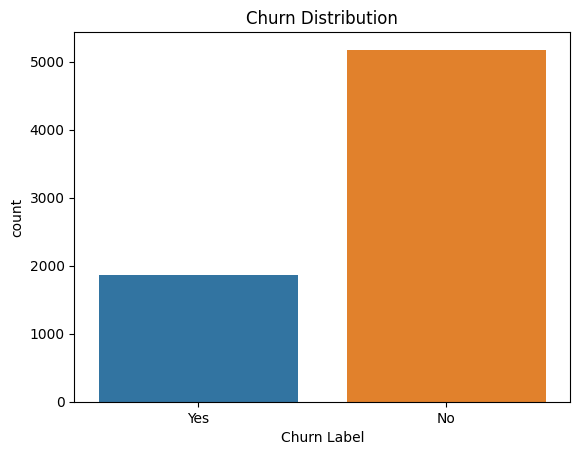

In [3]:
sns.countplot(data=df, x='Churn Label')
plt.title('Churn Distribution')
plt.show()

In [4]:
df['Churn Label'].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [6]:
print(df.isnull().sum() )

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64


In [7]:
df.shape

(7043, 33)

In [8]:
df.drop(['Churn Reason'], axis=1, inplace=True)

In [9]:
df.columns.tolist()

['CustomerID',
 'Count',
 'Country',
 'State',
 'City',
 'Zip Code',
 'Lat Long',
 'Latitude',
 'Longitude',
 'Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'Churn Label',
 'Churn Value',
 'Churn Score',
 'CLTV']

In [10]:
df["Count"].value_counts()

Count
1    7043
Name: count, dtype: int64

In [11]:
df.drop(['Count'], axis=1, inplace=True)

In [12]:
df.drop(['CustomerID'], axis=1, inplace=True)

In [13]:
df['Churn Value'].value_counts()

Churn Value
0    5174
1    1869
Name: count, dtype: int64

In [14]:
df.drop("Churn Label", axis=1, inplace=True)

In [15]:
df["Churn Score"].describe()

count    7043.000000
mean       58.699418
std        21.525131
min         5.000000
25%        40.000000
50%        61.000000
75%        75.000000
max       100.000000
Name: Churn Score, dtype: float64

In [16]:
df.groupby("Churn Value")["Churn Score"].mean()

Churn Value
0    50.098183
1    82.510433
Name: Churn Score, dtype: float64

In [17]:
df.isnull().sum().sort_values(ascending=False).head(10)

Country              0
Online Security      0
Churn Score          0
Churn Value          0
Total Charges        0
Monthly Charges      0
Payment Method       0
Paperless Billing    0
Contract             0
Streaming Movies     0
dtype: int64

In [18]:
df.isnull().sum().sort_values(ascending=False).head(10)

Country              0
Online Security      0
Churn Score          0
Churn Value          0
Total Charges        0
Monthly Charges      0
Payment Method       0
Paperless Billing    0
Contract             0
Streaming Movies     0
dtype: int64

In [19]:
df.drop("Churn Score", axis=1, inplace=True)

In [20]:
df.dtypes.value_counts()

object     21
int64       4
float64     3
Name: count, dtype: int64

In [21]:
df.select_dtypes(include="object").columns.tolist()

['Country',
 'State',
 'City',
 'Lat Long',
 'Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Total Charges']

In [22]:
for col in df.select_dtypes(include="object").columns:
    print(col, ":", df[col].nunique())

Country : 1
State : 1
City : 1129
Lat Long : 1652
Gender : 2
Senior Citizen : 2
Partner : 2
Dependents : 2
Phone Service : 2
Multiple Lines : 3
Internet Service : 3
Online Security : 3
Online Backup : 3
Device Protection : 3
Tech Support : 3
Streaming TV : 3
Streaming Movies : 3
Contract : 3
Paperless Billing : 2
Payment Method : 4
Total Charges : 6531


In [23]:
df.drop("Country", axis=1, inplace=True)

In [24]:
df.drop("State", axis=1, inplace=True)

In [25]:
df["City"].value_counts().head(10)

City
Los Angeles      305
San Diego        150
San Jose         112
Sacramento       108
San Francisco    104
Fresno            64
Long Beach        60
Oakland           52
Stockton          44
Bakersfield       40
Name: count, dtype: int64

In [26]:
df.drop("City", axis=1, inplace=True)

In [27]:
df["Lat Long"].head()

0    33.964131, -118.272783
1     34.059281, -118.30742
2    34.048013, -118.293953
3    34.062125, -118.315709
4    34.039224, -118.266293
Name: Lat Long, dtype: object

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Zip Code           7043 non-null   int64  
 1   Lat Long           7043 non-null   object 
 2   Latitude           7043 non-null   float64
 3   Longitude          7043 non-null   float64
 4   Gender             7043 non-null   object 
 5   Senior Citizen     7043 non-null   object 
 6   Partner            7043 non-null   object 
 7   Dependents         7043 non-null   object 
 8   Tenure Months      7043 non-null   int64  
 9   Phone Service      7043 non-null   object 
 10  Multiple Lines     7043 non-null   object 
 11  Internet Service   7043 non-null   object 
 12  Online Security    7043 non-null   object 
 13  Online Backup      7043 non-null   object 
 14  Device Protection  7043 non-null   object 
 15  Tech Support       7043 non-null   object 
 16  Streaming TV       7043 

In [29]:
df.drop("Lat Long", axis=1, inplace=True)

In [30]:
df.select_dtypes(include=["int64", "float64"]).columns.tolist()

['Zip Code',
 'Latitude',
 'Longitude',
 'Tenure Months',
 'Monthly Charges',
 'Churn Value',
 'CLTV']

In [31]:
df["Zip Code"].nunique()

1652

In [32]:
df.drop("Zip Code", axis=1, inplace=True)

In [33]:
df[["Tenure Months", "Monthly Charges", "CLTV"]].describe()

,Tenure Months,Monthly Charges,CLTV
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,4400.295755
std,24.559481,30.090047,1183.057152
min,0.000000,18.250000,2003.000000
25%,9.000000,35.500000,3469.000000
50%,29.000000,70.350000,4527.000000
75%,55.000000,89.850000,5380.500000
max,72.000000,118.750000,6500.000000


In [34]:
df.groupby("Churn Value")["CLTV"].mean()

Churn Value
0    4490.921337
1    4149.414660
Name: CLTV, dtype: float64

In [36]:
df[["Latitude", "Longitude"]].describe()

,Latitude,Longitude
count,7043.000000,7043.000000
mean,36.282441,-119.798880
std,2.455723,2.157889
min,32.555828,-124.301372
25%,34.030915,-121.815412
50%,36.391777,-119.730885
75%,38.224869,-118.043237
max,41.962127,-114.192901


In [35]:
df["Total Charges"].dtype

dtype('O')

In [36]:
(df["Total Charges"] == " ").sum()

11

In [37]:
df["Total Charges"] = pd.to_numeric(
    df["Total Charges"],
    errors="coerce"
)

In [38]:
df["Total Charges"].dtype

dtype('float64')

In [39]:
df["Total Charges"].isnull().sum()

11

In [40]:
df[df["Total Charges"].isnull()][["Tenure Months", "Monthly Charges", "Total Charges"]]

,Tenure Months,Monthly Charges,Total Charges
2234,0,52.55,NaN
2438,0,20.25,NaN
2568,0,80.85,NaN
2667,0,25.75,NaN
2856,0,56.05,NaN
4331,0,19.85,NaN
4687,0,25.35,NaN
5104,0,20.00,NaN
5719,0,19.70,NaN
6772,0,73.35,NaN


In [41]:
df["Total Charges"] = df["Total Charges"].fillna(0)

In [42]:
df["Total Charges"].isnull().sum()

0

In [43]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical Columns:")
print(cat_cols)

print("\nNumerical Columns:")
print(num_cols)

Categorical Columns:
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']

Numerical Columns:
['Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value', 'CLTV']


In [44]:
df.columns


Index(['Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner',
       'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines',
       'Internet Service', 'Online Security', 'Online Backup',
       'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies',
       'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges',
       'Total Charges', 'Churn Value', 'CLTV'],
      dtype='object')

In [45]:
df.dtypes

Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges        float64
Churn Value            int64
CLTV                   int64
dtype: object

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Latitude           7043 non-null   float64
 1   Longitude          7043 non-null   float64
 2   Gender             7043 non-null   object 
 3   Senior Citizen     7043 non-null   object 
 4   Partner            7043 non-null   object 
 5   Dependents         7043 non-null   object 
 6   Tenure Months      7043 non-null   int64  
 7   Phone Service      7043 non-null   object 
 8   Multiple Lines     7043 non-null   object 
 9   Internet Service   7043 non-null   object 
 10  Online Security    7043 non-null   object 
 11  Online Backup      7043 non-null   object 
 12  Device Protection  7043 non-null   object 
 13  Tech Support       7043 non-null   object 
 14  Streaming TV       7043 non-null   object 
 15  Streaming Movies   7043 non-null   object 
 16  Contract           7043 

In [47]:
X = df.drop("Churn Value", axis=1)
y = df["Churn Value"]

In [48]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [49]:
print(X_encoded.shape)

(7043, 33)


In [50]:
X_encoded.head()

,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,CLTV,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,33.964131,-118.272783,2,53.85,108.15,3239,True,False,False,False,...,False,False,False,False,False,False,True,False,False,True
1,34.059281,-118.307420,2,70.70,151.65,2701,False,False,False,True,...,False,False,False,False,False,False,True,False,True,False
2,34.048013,-118.293953,8,99.65,820.50,5372,False,False,False,True,...,False,True,False,True,False,False,True,False,True,False
3,34.062125,-118.315709,28,104.80,3046.05,5003,False,False,True,True,...,False,True,False,True,False,False,True,False,True,False
4,34.039224,-118.266293,49,103.70,5036.30,5340,True,False,False,True,...,False,True,False,True,False,False,True,False,False,False


In [51]:
X_encoded = X_encoded.astype(int)

In [52]:
X_encoded.head()

,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,CLTV,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,33,-118,2,53,108,3239,1,0,0,0,...,0,0,0,0,0,0,1,0,0,1
1,34,-118,2,70,151,2701,0,0,0,1,...,0,0,0,0,0,0,1,0,1,0
2,34,-118,8,99,820,5372,0,0,0,1,...,0,1,0,1,0,0,1,0,1,0
3,34,-118,28,104,3046,5003,0,0,1,1,...,0,1,0,1,0,0,1,0,1,0
4,34,-118,49,103,5036,5340,1,0,0,1,...,0,1,0,1,0,0,1,0,0,0


In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [54]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5634, 33)
(1409, 33)
(5634,)
(1409,)


In [55]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [56]:
y_pred = lr.predict(X_test)

In [57]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8076650106458482


In [58]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[920 115]
 [156 218]]


In [59]:

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.89      0.87      1035
           1       0.65      0.58      0.62       374

    accuracy                           0.81      1409
   macro avg       0.75      0.74      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [73]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [74]:
y_pred_rf = rf.predict(X_test)

In [75]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [76]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Accuracy: 0.801277501774308


In [77]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

[[935 100]
 [180 194]]


In [78]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

                            Feature  Importance
2                     Tenure Months    0.135277
4                     Total Charges    0.130591
5                              CLTV    0.106950
3                   Monthly Charges    0.089650
0                          Latitude    0.060523
1                         Longitude    0.058965
13     Internet Service_Fiber optic    0.040600
31  Payment Method_Electronic check    0.036092
9                    Dependents_Yes    0.034564
28                Contract_Two year    0.028684


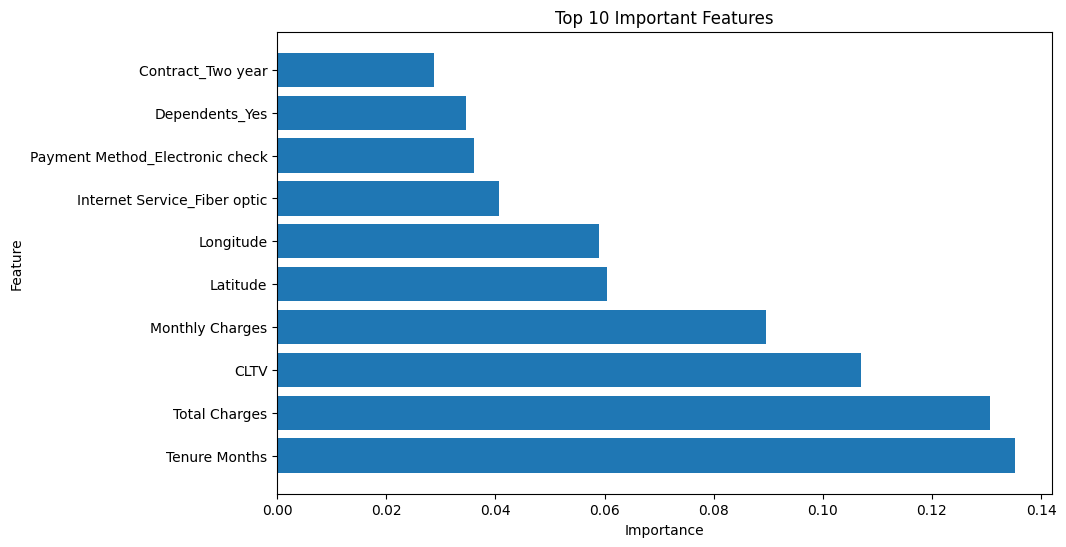

In [79]:
import matplotlib.pyplot as plt

top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10['Feature'], top10['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features")
plt.show()

AUC Score: 0.8405267508848072


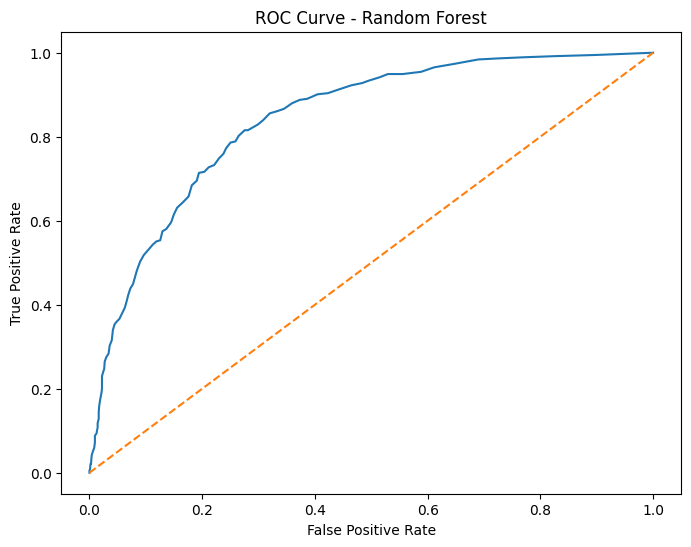

In [80]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob_rf = rf.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, y_prob_rf)
print("AUC Score:", auc)

fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.show()

In [81]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [82]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [83]:
y_pred_xgb = xgb.predict(X_test)

In [84]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

Accuracy: 0.7977288857345636


In [85]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [86]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred_xgb))

[[927 108]
 [177 197]]


In [87]:
from sklearn.metrics import roc_auc_score

y_prob_xgb = xgb.predict_proba(X_test)[:,1]

auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("AUC Score:", auc_xgb)

AUC Score: 0.8498204551912991


In [88]:

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred_xgb))

from sklearn.metrics import roc_auc_score
y_prob_xgb = xgb.predict_proba(X_test)[:,1]
print("AUC:", roc_auc_score(y_test, y_prob_xgb))

Accuracy: 0.7977288857345636
[[927 108]
 [177 197]]
AUC: 0.8498204551912991


In [89]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, None],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100, 200]},
             scoring='f1')

In [90]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}
0.5947453958768003


In [91]:
best_rf = grid_search.best_estimator_

y_pred_best = best_rf.predict(X_test)

In [92]:
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Accuracy: 0.7970191625266146
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [93]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}
0.5947453958768003


In [94]:
best_rf = grid_search.best_estimator_

y_pred_best = best_rf.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Accuracy: 0.7970191625266146
[[933 102]
 [184 190]]
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [95]:
from sklearn.metrics import roc_auc_score

y_prob_best = best_rf.predict_proba(X_test)[:,1]

print("AUC:", roc_auc_score(y_test, y_prob_best))

AUC: 0.8543982019685346


In [96]:
from sklearn.linear_model import LogisticRegression

lr_balanced = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

lr_balanced.fit(X_train, y_train)

y_pred_balanced = lr_balanced.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.52      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

